# 🚂 Sysslan IT Solutions — Internship Project
## Level 1: Data Overview
**Project:** Train Route Analysis and Journey Time Prediction  
**Level:** 1 — Data Overview  
**Dataset:** Indian Railways Train Schedule  
---

## 📦 Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Task 1.1 — Dataset Summary (Total Records & Columns)

In [2]:
# Load the dataset
df = pd.read_csv('Dataset1.csv')

print('=' * 50)
print('       📊 DATASET SUMMARY')
print('=' * 50)
print(f'✅ Total Records (Rows)  : {df.shape[0]:,}')
print(f'✅ Total Features (Cols) : {df.shape[1]}')
print(f'✅ Total Unique Trains   : {df["Train_No"].nunique():,}')
print(f'✅ Total Unique Stations : {df["Station_Code"].nunique():,}')
print('=' * 50)

       📊 DATASET SUMMARY
✅ Total Records (Rows)  : 186,074
✅ Total Features (Cols) : 12
✅ Total Unique Trains   : 11,113
✅ Total Unique Stations : 8,147


In [3]:
# First 5 rows
print('📋 First 5 Rows of Dataset:')
df.head()

📋 First 5 Rows of Dataset:


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [4]:
# Column names and data types
print('📋 Column Names & Data Types:')
print(df.dtypes)
print()
print('📋 Dataset Info:')
df.info()

📋 Column Names & Data Types:
SN                 int64
Train_No           int64
Station_Code      object
1A                 int64
2A                 int64
3A                 int64
SL                 int64
Station_Name      object
Route_Number       int64
Arrival_time      object
Departure_Time    object
Distance           int64
dtype: object

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-nu

---
## 🗺️ Task 1.2 — Train-wise Table: Route Start & End Stations

In [5]:
# For each train: first station = source, last station = destination
train_routes = df.groupby('Train_No').agg(
    Start_Station_Code=('Station_Code', 'first'),
    Start_Station_Name=('Station_Name', 'first'),
    End_Station_Code=('Station_Code', 'last'),
    End_Station_Name=('Station_Name', 'last'),
    Total_Stops=('Station_Code', 'count'),
    Total_Distance_km=('Distance', 'max')
).reset_index()

print(f'🚂 Train-wise Route Table (showing first 15 trains):')
print('=' * 90)
train_routes.head(15)

🚂 Train-wise Route Table (showing first 15 trains):


,Train_No,Start_Station_Code,Start_Station_Name,End_Station_Code,End_Station_Name,Total_Stops,Total_Distance_km
0,107,SWV,SAWANTWADI R,MAO,MADGOAN JN.,4,78
1,108,MAO,MADGOAN JN.,SWV,SAWANTWADI R,4,83
2,128,MAO,MADGOAN JN.,KOP,CHHATRAPATI,22,978
3,290,DSJ,DELHI-SAFDAR,DSJ,DELHI-SAFDAR,14,2694
4,401,AWB,AURANGABAD,BSB,VARANASI JN.,12,1618
5,421,LKO,LUCKNOW JN.,SVDK,SHRI MATA VA,5,1276
6,422,SVDK,SHRI MATA VA,LKO,LUCKNOW JN.,5,1277
7,477,SSA,SIRSA,SSA,SIRSA,14,2616
8,502,RJPB,RAJENDRANAGA,UMB,AMBALA CANTT,9,1206
9,504,PNBE,PATNA JN.,BTI,BATHINDA JN,3,1313


In [6]:
# Save this table
train_routes.to_csv('train_routes_summary.csv', index=False)
print(f'✅ Train routes table saved! Total trains: {len(train_routes)}')

✅ Train routes table saved! Total trains: 11113


---
## 📏 Task 1.3 — Basic Statistics: Distance & Number of Stops

In [7]:
# Distance statistics
print('📊 Distance Statistics (per train — max distance = total route distance):')
print('=' * 55)
dist_stats = train_routes['Total_Distance_km'].describe()
print(f"Mean Distance   : {dist_stats['mean']:.2f} km")
print(f"Min Distance    : {dist_stats['min']:.2f} km")
print(f"Max Distance    : {dist_stats['max']:.2f} km")
print(f"Median Distance : {dist_stats['50%']:.2f} km")
print(f"Std Deviation   : {dist_stats['std']:.2f} km")

print()
print('🚉 Number of Stops Statistics (per train):')
print('=' * 55)
stops_stats = train_routes['Total_Stops'].describe()
print(f"Mean Stops      : {stops_stats['mean']:.2f}")
print(f"Min Stops       : {stops_stats['min']:.0f}")
print(f"Max Stops       : {stops_stats['max']:.0f}")
print(f"Median Stops    : {stops_stats['50%']:.0f}")
print(f"Std Deviation   : {stops_stats['std']:.2f}")

📊 Distance Statistics (per train — max distance = total route distance):
Mean Distance   : 348.87 km
Min Distance    : 1.00 km
Max Distance    : 4260.00 km
Median Distance : 82.00 km
Std Deviation   : 596.18 km

🚉 Number of Stops Statistics (per train):
Mean Stops      : 16.74
Min Stops       : 2
Max Stops       : 118
Median Stops    : 15
Std Deviation   : 12.99


In [8]:
# Full describe table
print('📋 Full Statistical Summary:')
train_routes[['Total_Distance_km', 'Total_Stops']].describe().round(2)

📋 Full Statistical Summary:


,Total_Distance_km,Total_Stops
count,11113.00,11113.00
mean,348.87,16.74
std,596.18,12.99
min,1.00,2.00
25%,38.00,8.00
50%,82.00,15.00
75%,324.00,22.00
max,4260.00,118.00


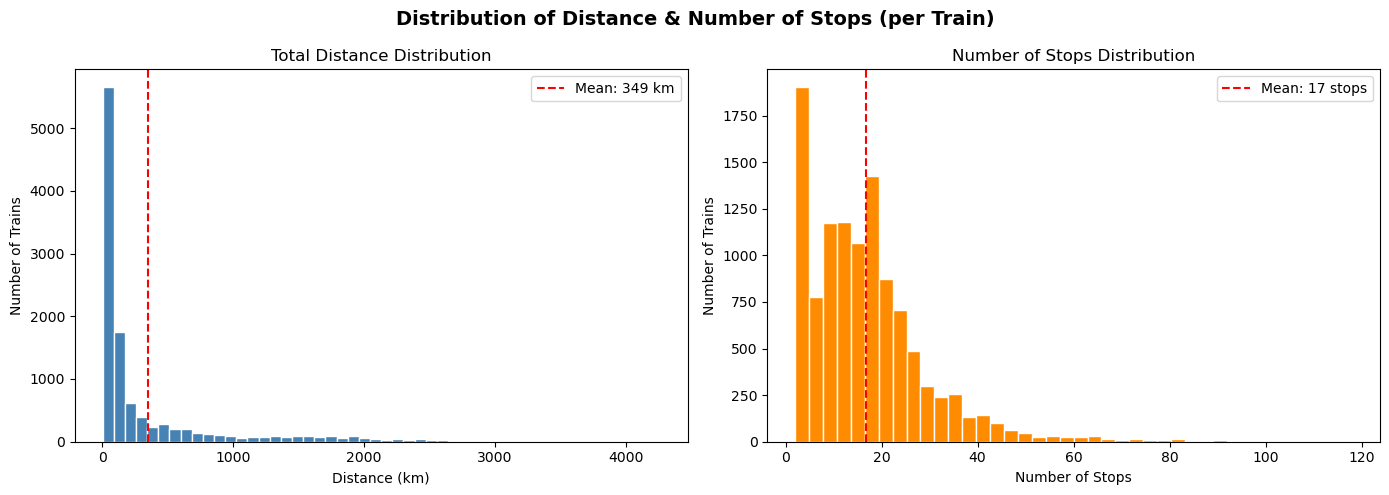

✅ Chart saved!


In [9]:
# Quick visualization — Distribution of Distance & Stops
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Distance & Number of Stops (per Train)', fontsize=14, fontweight='bold')

# Distance distribution
axes[0].hist(train_routes['Total_Distance_km'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Total Distance Distribution')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Number of Trains')
axes[0].axvline(train_routes['Total_Distance_km'].mean(), color='red', linestyle='--', label=f"Mean: {train_routes['Total_Distance_km'].mean():.0f} km")
axes[0].legend()

# Stops distribution
axes[1].hist(train_routes['Total_Stops'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Number of Stops Distribution')
axes[1].set_xlabel('Number of Stops')
axes[1].set_ylabel('Number of Trains')
axes[1].axvline(train_routes['Total_Stops'].mean(), color='red', linestyle='--', label=f"Mean: {train_routes['Total_Stops'].mean():.0f} stops")
axes[1].legend()

plt.tight_layout()
plt.savefig('Level1_Distance_Stops_Distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

---
## 🔍 Task 1.4 — Missing, Null & Inconsistent Values

In [10]:
# Check missing / null values
print('🔍 Missing Value Check (Column-wise):')
print('=' * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df)
print()
if missing.sum() == 0:
    print('✅ No missing values found in the dataset!')
else:
    print(f'⚠️  Total missing values: {missing.sum()}')

🔍 Missing Value Check (Column-wise):
                Missing Count  Missing %
SN                          0        0.0
Train_No                    0        0.0
Station_Code                0        0.0
1A                          0        0.0
2A                          0        0.0
3A                          0        0.0
SL                          0        0.0
Station_Name                0        0.0
Route_Number                0        0.0
Arrival_time                0        0.0
Departure_Time              0        0.0
Distance                    0        0.0

✅ No missing values found in the dataset!


In [11]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f'🔁 Duplicate Rows: {duplicates}')

# Check inconsistent time values (00:00:00 is used as placeholder)
# First station has Arrival = 00:00:00 and last station has Departure = 00:00:00
# This is intentional — let's verify
placeholder_arrival = (df['Arrival_time'] == '00:00:00').sum()
placeholder_departure = (df['Departure_Time'] == '00:00:00').sum()

print()
print('🕐 Placeholder Time Values (00:00:00):')
print(f'   Arrival_time  = 00:00:00 → {placeholder_arrival:,} rows (first stop of each train)')
print(f'   Departure_Time = 00:00:00 → {placeholder_departure:,} rows (last stop of each train)')
print('   ℹ️  These are expected — first station has no arrival, last has no departure.')

🔁 Duplicate Rows: 0

🕐 Placeholder Time Values (00:00:00):
   Arrival_time  = 00:00:00 → 2,003 rows (first stop of each train)
   Departure_Time = 00:00:00 → 1,970 rows (last stop of each train)
   ℹ️  These are expected — first station has no arrival, last has no departure.


In [12]:
# Check for negative or zero distances (only first station should have 0)
zero_dist = df[df['Distance'] == 0]
negative_dist = df[df['Distance'] < 0]

print(f'📏 Zero Distance Rows   : {len(zero_dist)} (expected — one per train = {df["Train_No"].nunique()} trains)')
print(f'❌ Negative Distance Rows: {len(negative_dist)}')

# Check fare columns (1A, 2A, 3A, SL) — 100 is default/minimum fare
print()
print('💰 Fare Columns — Minimum values check:')
for col in ['1A', '2A', '3A', 'SL']:
    print(f'   {col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.0f}')

📏 Zero Distance Rows   : 11124 (expected — one per train = 11113 trains)
❌ Negative Distance Rows: 0

💰 Fare Columns — Minimum values check:
   1A: min=100, max=21400, mean=1507
   2A: min=100, max=17140, mean=1225
   3A: min=100, max=12880, mean=944
   SL: min=100, max=8620, mean=663


In [13]:
# Final summary card
print('=' * 55)
print('       ✅ LEVEL 1 SUMMARY — DATA OVERVIEW')
print('=' * 55)
print(f'  Total Records          : {df.shape[0]:,}')
print(f'  Total Columns          : {df.shape[1]}')
print(f'  Unique Trains          : {df["Train_No"].nunique():,}')
print(f'  Unique Stations        : {df["Station_Code"].nunique():,}')
print(f'  Missing Values         : {df.isnull().sum().sum()}')
print(f'  Duplicate Rows         : {duplicates}')
print(f'  Avg Distance per Train : {train_routes["Total_Distance_km"].mean():.2f} km')
print(f'  Avg Stops per Train    : {train_routes["Total_Stops"].mean():.2f}')
print(f'  Placeholder Times      : {placeholder_arrival + placeholder_departure:,} (expected)')
print('=' * 55)
print('  ✅ Dataset is clean and ready for Level 2!')
print('=' * 55)

       ✅ LEVEL 1 SUMMARY — DATA OVERVIEW
  Total Records          : 186,074
  Total Columns          : 12
  Unique Trains          : 11,113
  Unique Stations        : 8,147
  Missing Values         : 0
  Duplicate Rows         : 0
  Avg Distance per Train : 348.87 km
  Avg Stops per Train    : 16.74
  Placeholder Times      : 3,973 (expected)
  ✅ Dataset is clean and ready for Level 2!
